# FSL FAST
## OHBM 2025 Hackathon Demo

**Autor:** Monika Doerig

**Citation:**

__FSL FAST__:
- Zhang Y, Brady M, Smith S. Segmentation of brain MR images through a hidden Markov random field model and the expectation-maximization algorithm. IEEE Trans Med Imaging. 2001 Jan;20(1):45-57. doi: [10.1109/42.906424](https://ieeexplore.ieee.org/document/906424/). PMID: 11293691.

- [FSL wiki: FAST](https://fsl.fmrib.ox.ac.uk/fsl/docs/#/structural/fast?id=fast)

__Opensource Data from OpenNeuro:__
- Kelly AMC and Uddin LQ and Biswal BB and Castellanos FX and Milham MP (2018). Flanker task (event-related). [OpenNeuro Dataset ds000102](https://openneuro.org/datasets/ds000102/versions/00001)
- Kelly, A.M., Uddin, L.Q., Biswal, B.B., Castellanos, F.X., Milham, M.P. (2008). Competition between functional brain networks mediates behavioral variability. Neuroimage, 39(1):527-37

### Introduction

*From FSL wiki:* "FAST (FMRIB's Automated Segmentation Tool) segments a 3D image of the brain into different tissue types (Grey Matter, White Matter, CSF, etc.), whilst also correcting for spatial intensity variations (also known as bias field or RF inhomogeneities). The underlying method is based on a hidden Markov random field model and an associated Expectation-Maximization algorithm. The whole process is fully automated and can also produce a bias field-corrected input image and a probabilistic and/or partial volume tissue segmentation. It is robust and reliable, compared to most finite mixture model-based methods, which are sensitive to noise."

### Load FSL

In [12]:
import module
await module.purge()
await module.load("fsl/6.0.7.16")
await module.list()

['fsl/6.0.7.16']

### Download data from OpenNeuro

In [3]:
PATTERN = "sub-01/anat"
! datalad install https://github.com/OpenNeuroDatasets/ds000102.git
! cd ds000102 && datalad get $PATTERN

Cloning:   0%|                             | 0.00/2.00 [00:00<?, ? candidates/s]
Enumerating: 0.00 Objects [00:00, ? Objects/s]
                                              
Counting:   0%|                               | 0.00/27.0 [00:00<?, ? Objects/s]
                                                                                
Compressing:   0%|                            | 0.00/23.0 [00:00<?, ? Objects/s]
                                                                                
Receiving:   0%|                             | 0.00/2.15k [00:00<?, ? Objects/s]
                                                                                
Resolving:   0%|                                | 0.00/537 [00:00<?, ? Deltas/s]
[INFO   ] scanning for unlocked files (this may take some time)                 
[INFO   ] Remote origin not usable by git-annex; setting annex-ignore 
[INFO   ] access to 1 dataset sibling s3-PRIVATE not auto-enabled, enable with:
| 		datalad siblings -d "/

In [7]:
!cd ds000102/sub-01/anat && ls

sub-01_T1w.nii.gz


In [4]:
%%capture
!pip install nilearn 

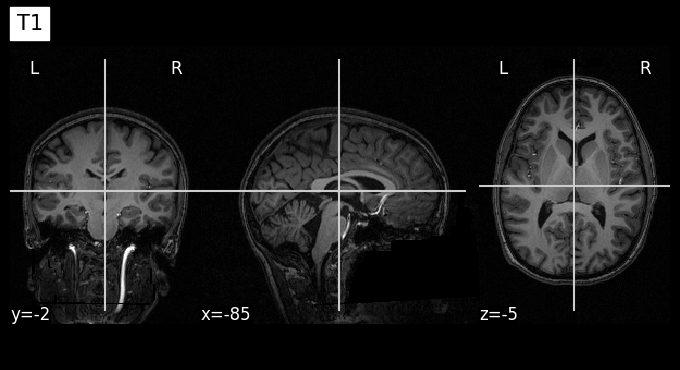

In [13]:
from nilearn import plotting
import nibabel as nib

plotting.plot_anat("./ds000102/sub-01/anat/sub-01_T1w.nii.gz", title="T1", dim=-1.0)

### Apply skull-stripping with FSL's BET

In [9]:
! bet -h 


Usage:    bet <input> <output> [options]

Main bet2 options:
  -o          generate brain surface outline overlaid onto original image
  -m          generate binary brain mask
  -s          generate approximate skull image
  -n          don't generate segmented brain image output
  -f <f>      fractional intensity threshold (0->1); default=0.5; smaller values give larger brain outline estimates
  -g <g>      vertical gradient in fractional intensity threshold (-1->1); default=0; positive values give larger brain outline at bottom, smaller at top
  -r <r>      head radius (mm not voxels); initial surface sphere is set to half of this
  -c <x y z>  centre-of-gravity (voxels not mm) of initial mesh surface.
  -t          apply thresholding to segmented brain image and mask
  -e          generates brain surface as mesh in .vtk format

Variations on default bet2 functionality (mutually exclusive options):
  (default)   just run bet2
  -R          robust brain centre estimation (iterates BE

In [15]:
! bet ./ds000102/sub-01/anat/sub-01_T1w.nii.gz sub-01_T1w_brain.nii.gz

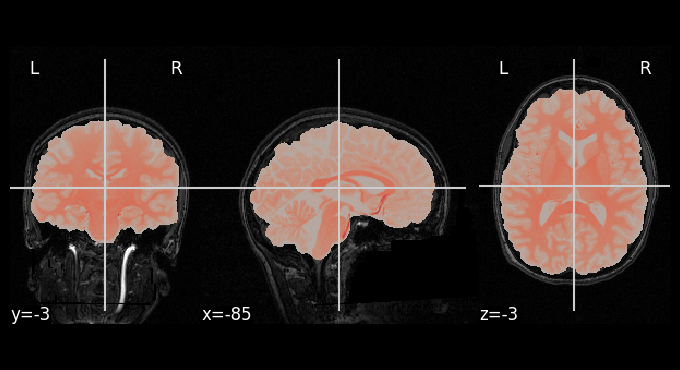

In [13]:
plotting.plot_roi('sub-01_T1w_brain.nii.gz', 
                  bg_img='./ds000102/sub-01/anat/sub-01_T1w.nii.gz', 
                  dim=-1,
                  cmap='Reds')

### Segmentation of the anatomical image into CSF, Grey Matter, White Matter

In [14]:
!fast -h


Part of FSL (ID: "")
FAST 
Copyright(c) 2004-2012, University of Oxford

Usage: 
fast [options] file(s)

Optional arguments (You may optionally specify one or more of):
	-n,--class	number of tissue-type classes; default=3
	-I,--iter	number of main-loop iterations during bias-field removal; default=4
	-l,--lowpass	bias field smoothing extent (FWHM) in mm; default=20
	-t,--type	type of image 1=T1, 2=T2, 3=PD; default=T1
	-f,--fHard	initial segmentation spatial smoothness (during bias field estimation); default=0.02
	-g,--segments	outputs a separate binary image for each tissue type
	-a <standard2input.mat> initialise using priors; you must supply a FLIRT transform
	-A <prior1> <prior2> <prior3>    alternative prior images
	--nopve	turn off PVE (partial volume estimation)
	-b		output estimated bias field
	-B		output bias-corrected image
	-N,--nobias	do not remove bias field
	-S,--channels	number of input images (channels); default 1
	-o,--out	output basename
	-P,--Prior	use priors throug

#### NiiVue: Visualization of the binary segment 
We can create our own colormaps by defining an object with specific properties: R, G, B (arrays of red, green, blue values from 0-255), A (alpha/opacity values from 0-255), and I (intensity values defining the control points for the mapping, corresponding to RGBA points).

In [16]:
#PVE 0 = CSF ; PVE 1 = Gray Matter ; PVE 2 = White Matter
!fast -o sub-01_fast -v sub-01_T1w_brain.nii.gz

In [2]:
from ipyniivue import NiiVue

nv = NiiVue()

nv.load_volumes([{"path": "sub-01_fast_seg.nii.gz"}])

# Define the custom colormap structure (CSF = blueish, GM = redish, WM = gray)
custom_cmap = {
    "R": [0, 0, 120, 175],    # Red channel values at control points 
    "G": [0, 90, 60, 185],    # Green channel values at control points
    "B": [0, 120, 60, 175],   # Blue channel values at control point
    "A": [0, 255, 255, 255],  # Alpha values
    "I": [0, 85, 170, 255],   # Intensity values corresponding to R,G,B,A points
}

# Add the colormap to Niivue with a unique name
nv.add_colormap("CustomSegMap", custom_cmap)
# Apply the custom colormap (to the first volume id)
nv.set_colormap(nv.volumes[0].id, "CustomSegMap")
# Display colorbar alongside the image to show the current colormap and its corresponding data range
nv.is_colorbar = True

nv

NiiVue(height=300)

In [1]:
from IPython.display import Image
Image(url = 'https://raw.githubusercontent.com/neurodesk/example-notebooks/refs/heads/main/books/images/fast_segmentation.png')